In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import yaml
from PIL import Image

In [2]:
import os
import shutil

# Define paths
downloads_folder = os.path.expanduser("~/Downloads/css-data")  # Downloads/css-data
destination_folder = "css-data"  # Target folder in current directory

# Copy folder to current directory
if os.path.exists(downloads_folder):
    shutil.copytree(downloads_folder, destination_folder)
    print(f"Folder copied to: {os.path.abspath(destination_folder)}")
else:
    print("Error: Folder not found in Downloads. Check the name!")

Folder copied to: c:\Users\baiju\Downloads\css-data\css-data


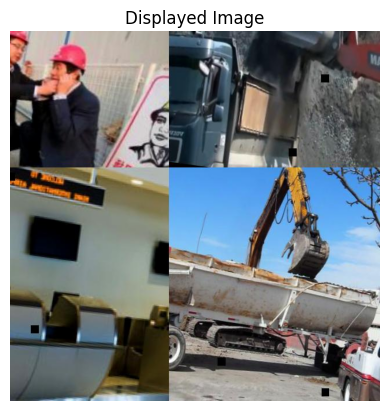

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# Path to the image
image_path = 'css-data/train/images/-1680-_png_jpg.rf.aac88b5b6fa0becf6442572810f8cf76.jpg'

# Open and display the image
def display_image(image_path):
    try:
        img = Image.open(image_path)  # Open the image
        plt.imshow(img)  # Display the image using matplotlib
        plt.axis('off')  # Hide the axes for a cleaner look
        plt.title('Displayed Image')  # Optional title
        plt.show()  # Show the plot
    except Exception as e:
        print(f"Error: {e}")

# Call the function to display the image
display_image(image_path)

In [6]:
import os
import pandas as pd

# Define the path to the images directory
image_dir = 'css-data/train/images'

# Get a list of all image file names in the directory
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]

# Create a pandas DataFrame with the file names or full paths
image_data = pd.DataFrame({
    'image_path': [os.path.join(image_dir, img) for img in image_files]
})

# Display the DataFrame
print(image_data.head())

                                          image_path
0  css-data/train/images\-1670-_png_jpg.rf.0463ed...
1  css-data/train/images\-1670-_png_jpg.rf.3cb172...
2  css-data/train/images\-1670-_png_jpg.rf.7da967...
3  css-data/train/images\-1670-_png_jpg.rf.b42b26...
4  css-data/train/images\-1670-_png_jpg.rf.dd5cb0...


In [7]:
image_data.shape

(2605, 1)

In [8]:
import os
import pandas as pd

# Define the path to the labels directory
label_dir = 'css-data/train/labels'

# Initialize an empty list to store the annotation data
annotations = []

# Iterate through each label file
for label_file in os.listdir(label_dir):
    # Construct the full file path
    label_path = os.path.join(label_dir, label_file)

    # Read the contents of the label file
    with open(label_path, 'r') as file:
        for line in file:
            # Split the line into parts and add to annotations
            annotations.append([label_file, *line.strip().split()])

# Create a DataFrame from the annotations
annotations_df = pd.DataFrame(annotations, columns=['label_file', 'class_id', 'x_center', 'y_center', 'width', 'height'])
annotations_df.head()

,label_file,class_id,x_center,y_center,width,height
0,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,0,0.0775416543763631,0.39375,0.09097043364502548,0.059375
1,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,0,0.01640625,0.41328125,0.0328125,0.1203125
2,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,3,0.04682291950167361,0.43671875,0.03935339149054773,0.05
3,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,3,0.09124054001317838,0.45625,0.05019998789975162,0.034375
4,-1670-_png_jpg.rf.0463edb430019e01ec79eed27a63...,5,0.16328125,0.4203125,0.3265625,0.178125


In [9]:
import pandas as pd
import os

# Define paths
INPUT_DIR = 'css-data'
IMAGE_DIR = {'train': os.path.join(INPUT_DIR, 'train', 'images'),
             'valid': os.path.join(INPUT_DIR, 'valid', 'images'),
             'test': os.path.join(INPUT_DIR, 'test', 'images')}

LABEL_DIR = {'train': os.path.join(INPUT_DIR, 'train', 'labels'),
             'valid': os.path.join(INPUT_DIR, 'valid', 'labels'),
             'test': os.path.join(INPUT_DIR, 'test', 'labels')}

# Class names (replace as necessary)
classes = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest',
           'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']

def get_image_label_dataframe(mode):
    image_paths = []
    image_labels = []

    # Iterate over label files
    for label_file in os.listdir(LABEL_DIR[mode]):
        # Get image file name corresponding to label
        img_file = label_file.replace('.txt', '.jpg')
        img_path = os.path.join(IMAGE_DIR[mode], img_file)

        # Read label file
        with open(os.path.join(LABEL_DIR[mode], label_file), 'r') as f:
            labels = f.readlines()

        # Get class IDs from the label file
        class_ids = [int(line.split()[0]) for line in labels]

        # Map class IDs to class names
        class_names = [classes[class_id] for class_id in class_ids]

        # Store image path and associated labels
        image_paths.append(img_path)
        image_labels.append(class_names)

    # Create DataFrame
    df = pd.DataFrame({
        'Image_Path': image_paths,
        'Labels': image_labels
    })

    return df

# Create DataFrames for train, valid, and test
train_df = get_image_label_dataframe('train')
valid_df = get_image_label_dataframe('valid')
test_df = get_image_label_dataframe('test')

# Combine all into a single DataFrame
df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

# Display the DataFrame
print(df.head())


                                          Image_Path  \
0  css-data\train\images\-1670-_png_jpg.rf.0463ed...   
1  css-data\train\images\-1670-_png_jpg.rf.3cb172...   
2  css-data\train\images\-1670-_png_jpg.rf.7da967...   
3  css-data\train\images\-1670-_png_jpg.rf.b42b26...   
4  css-data\train\images\-1670-_png_jpg.rf.dd5cb0...   

                                              Labels  
0  [Hardhat, Hardhat, NO-Mask, NO-Mask, Person, P...  
1  [Person, Person, NO-Mask, NO-Safety Vest, NO-S...  
2  [Hardhat, NO-Hardhat, NO-Safety Vest, NO-Safet...  
3  [Hardhat, Hardhat, NO-Mask, NO-Mask, NO-Safety...  
4  [Hardhat, Hardhat, NO-Mask, NO-Mask, NO-Safety...  


In [10]:
train_df.head()

,Image_Path,Labels
0,css-data\train\images\-1670-_png_jpg.rf.0463ed...,"[Hardhat, Hardhat, NO-Mask, NO-Mask, Person, P..."
1,css-data\train\images\-1670-_png_jpg.rf.3cb172...,"[Person, Person, NO-Mask, NO-Safety Vest, NO-S..."
2,css-data\train\images\-1670-_png_jpg.rf.7da967...,"[Hardhat, NO-Hardhat, NO-Safety Vest, NO-Safet..."
3,css-data\train\images\-1670-_png_jpg.rf.b42b26...,"[Hardhat, Hardhat, NO-Mask, NO-Mask, NO-Safety..."
4,css-data\train\images\-1670-_png_jpg.rf.dd5cb0...,"[Hardhat, Hardhat, NO-Mask, NO-Mask, NO-Safety..."


In [11]:
train_df.shape

(2605, 2)

In [12]:
train_df.isnull().sum()

Image_Path    0
Labels        0
dtype: int64

In [13]:
test_df.head()

,Image_Path,Labels
0,css-data\test\images\-4405-_png_jpg.rf.82b5c10...,"[Hardhat, NO-Mask, NO-Safety Vest, Person]"
1,css-data\test\images\000005_jpg.rf.96e9379ccae...,"[Hardhat, Hardhat, NO-Mask, NO-Mask, NO-Safety..."
2,css-data\test\images\002551_jpg.rf.ce4b9f93416...,"[Hardhat, Hardhat, Hardhat, NO-Mask, NO-Safety..."
3,css-data\test\images\003357_jpg.rf.9867f91e880...,"[Hardhat, Safety Cone, NO-Safety Vest, NO-Mask..."
4,css-data\test\images\004063_jpg.rf.1b7cdc4035b...,"[Hardhat, Hardhat, Hardhat, Hardhat, NO-Hardha..."


In [14]:
test_df.shape

(82, 2)

In [15]:
test_df.isnull().sum()

Image_Path    0
Labels        0
dtype: int64

In [16]:
valid_df.head()

,Image_Path,Labels
0,css-data\valid\images\-1079-_png_jpg.rf.19092a...,"[Hardhat, Hardhat, Person, Person, Person, Per..."
1,css-data\valid\images\-1429-_png_jpg.rf.78a789...,"[Hardhat, Hardhat, NO-Safety Vest, NO-Mask, NO..."
2,css-data\valid\images\-1969-_png_jpg.rf.41dd58...,"[Hardhat, NO-Mask, NO-Safety Vest, Person]"
3,css-data\valid\images\-1989-_png_jpg.rf.8cb3d6...,"[Hardhat, Hardhat, Hardhat, Hardhat, Hardhat, ..."
4,css-data\valid\images\-211-_png_jpg.rf.eac228e...,"[Hardhat, Safety Vest, Safety Vest, NO-Mask, N..."


In [17]:
valid_df.shape

(114, 2)

In [18]:
valid_df.isnull().sum()

Image_Path    0
Labels        0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2801 entries, 0 to 2800
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image_Path  2801 non-null   object
 1   Labels      2801 non-null   object
dtypes: object(2)
memory usage: 43.9+ KB


In [20]:
df.describe()

,Image_Path,Labels
count,2801,2801
unique,2801,2630
top,css-data\test\images\youtube-840_jpg.rf.974a83...,[]
freq,1,24


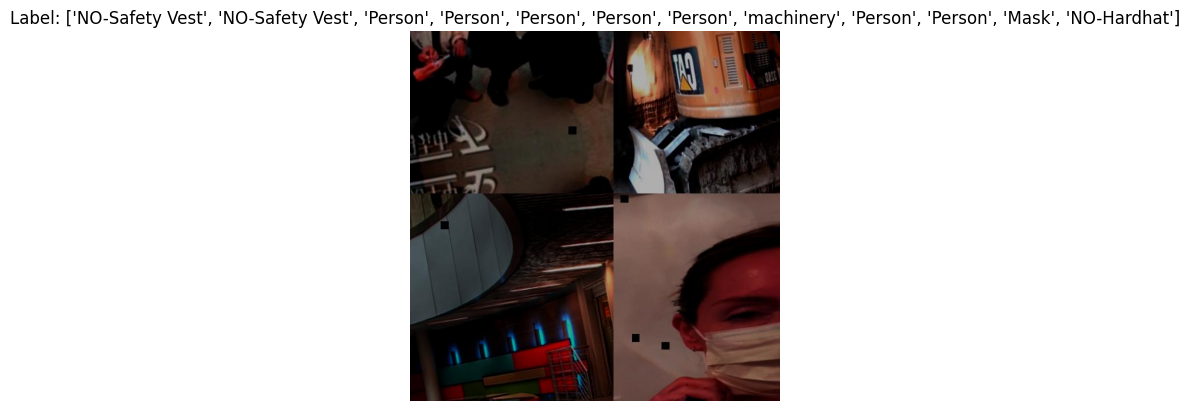

In [21]:
def display_image_and_label(df, index):
    image_path = df.loc[index, 'Image_Path']  # Get the image path
    label = df.loc[index, 'Labels']  # Get the label

    # Open the image
    img = Image.open(image_path)

    # Display the image
    plt.imshow(img)
    plt.axis('off')  # Turn off the axis
    plt.title(f'Label: {label}')  # Display the label as title
    plt.show()

# Example: Display the first image and label
display_image_and_label(df, 5)

In [22]:
num_classes=len(classes)

class_idx = {str(i): classes[i] for i in range(num_classes)}
class_stat = {}
data_len = {}
class_info=[]
for mode in ['train', 'valid', 'test']:
    class_count = {cls: 0 for cls in classes}
    path = os.path.join(INPUT_DIR, mode, 'labels')

    # Iterate through files in the label directory
    for file in os.listdir(path):
        with open(os.path.join(path, file)) as f:
            lines = f.readlines()

        # Increment the class count for each unique class in the file
        unique_classes = {line[0] for line in lines}
        for cls in unique_classes:
            class_count[class_idx[cls]] += 1

    data_len[mode] = len(os.listdir(path))
    class_stat[mode] = class_count
    class_info.append({'Mode': mode, **class_count, 'Data_Volume': data_len[mode]})
dataset_stats_df = pd.DataFrame(class_info)
with pd.option_context('display.max_columns', None):
    display(dataset_stats_df)


,Mode,Hardhat,Mask,NO-Hardhat,NO-Mask,NO-Safety Vest,Person,Safety Cone,Safety Vest,machinery,vehicle,Data_Volume
0,train,1314,1096,1380,1531,1864,2526,631,1319,2101,744,2605
1,valid,42,19,37,44,56,84,13,28,26,16,114
2,test,30,16,25,30,36,59,8,22,22,15,82


C:\Users\baiju\AppData\Local\Temp\ipykernel_24360\1011506476.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\baiju\AppData\Local\Temp\ipykernel_24360\1011506476.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\baiju\AppData\Local\Temp\ipykernel_24360\1011506476.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


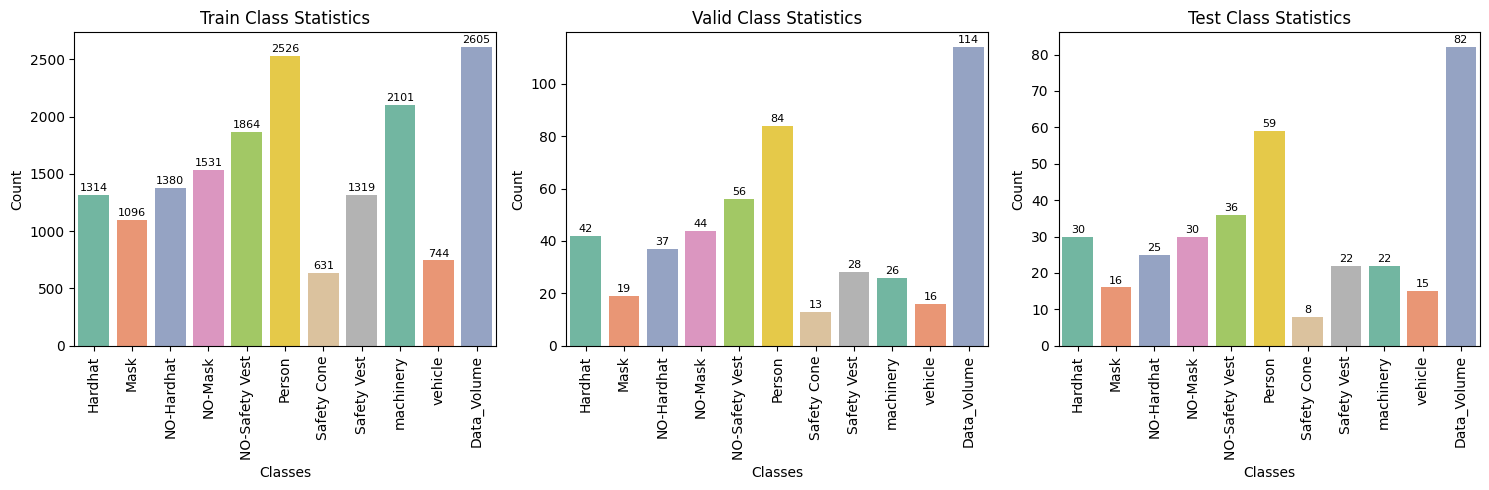

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Побудова вертикальних стовпчикових діаграм для кожного режиму в підграфіках
for i, mode in enumerate(['train', 'valid', 'test']):
    subset = dataset_stats_df[dataset_stats_df['Mode'] == mode].drop(columns='Mode')
    subset = subset.melt(var_name='Classes', value_name='Count')  # Перетворення на довгий формат

    sns.barplot(
        data=subset,
        x='Classes',
        y='Count',
        ax=axes[i],
        palette='Set2'
    )

    axes[i].set_title(f'{mode.capitalize()} Class Statistics')
    axes[i].set_xlabel('Classes')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=90)

    # Додаємо підписи над кожним стовпчиком
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                         textcoords='offset points')

plt.tight_layout()
plt.show()